Starting Monte Carlo Simulations...
Processing Init_Sigma = 0.1...
Processing Init_Sigma = 0.5...
Processing Init_Sigma = 1.5...
Processing Init_Sigma = 4.0...
Saving figure to Fig8_Grouped_SSR.eps...


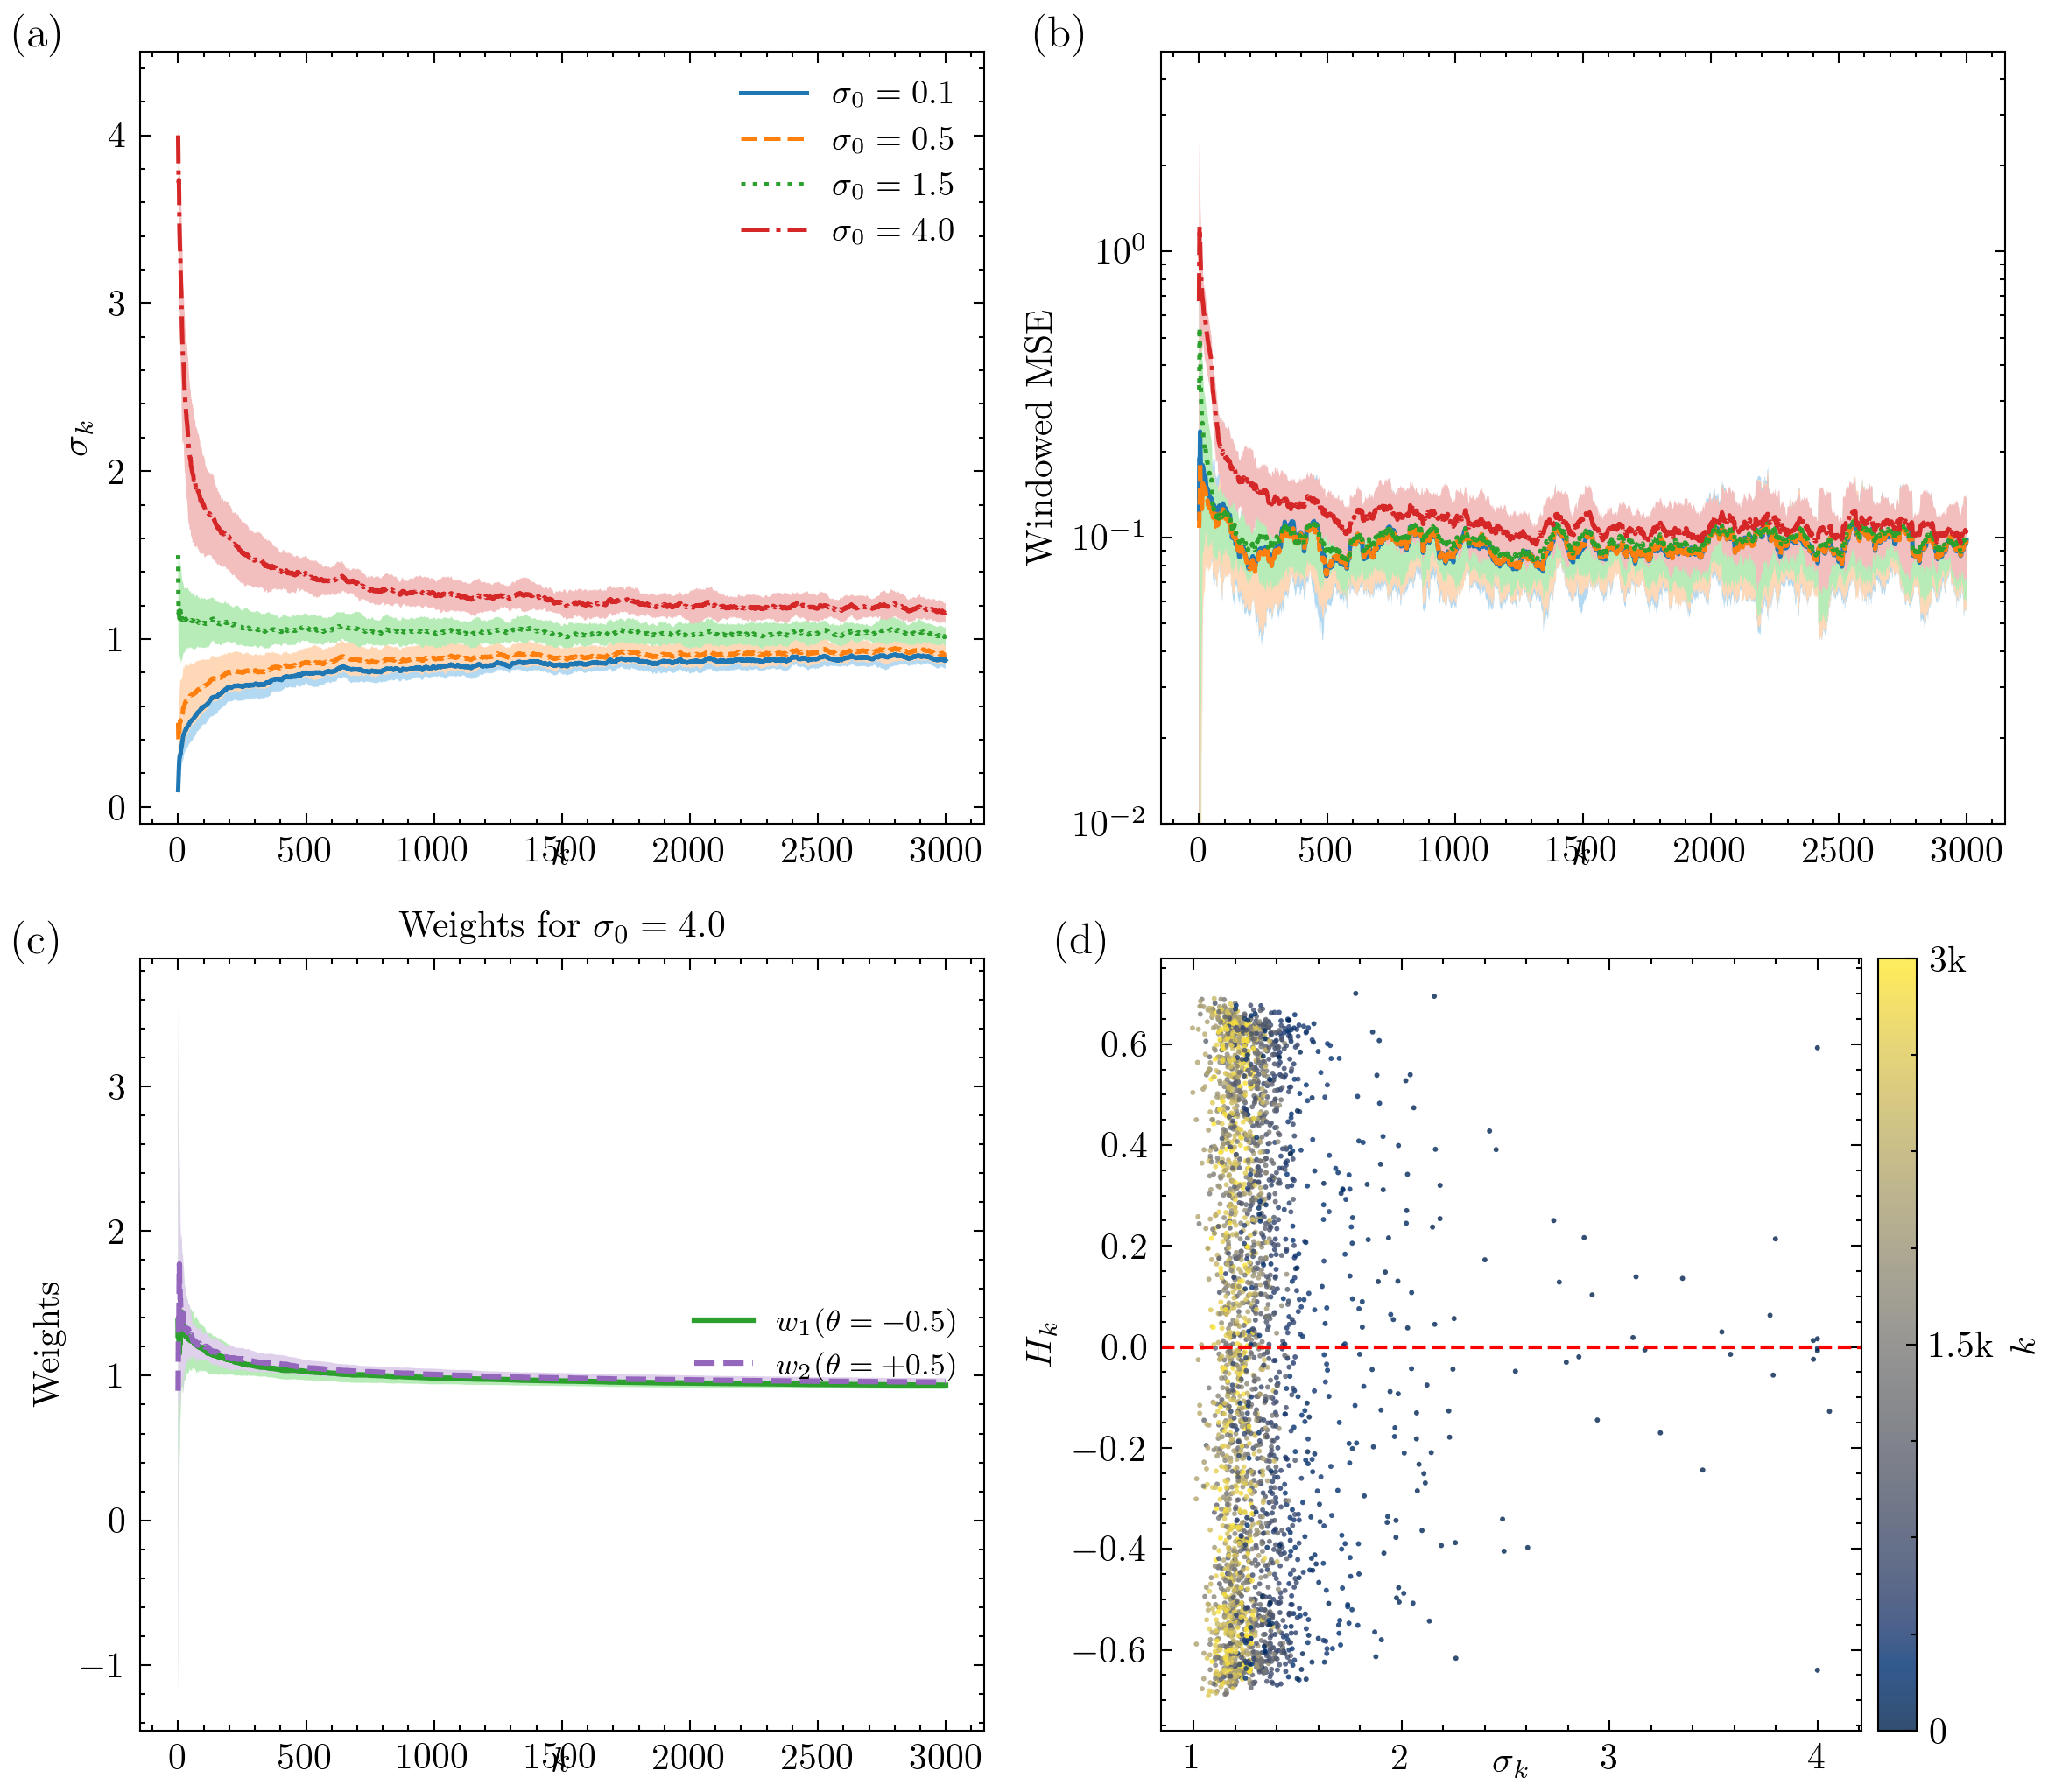


Final Results (Averaged over last 100 steps, 20 trials)
Init  0.1: Sigma=0.8857, W1=0.7876, W2=0.7972, MSE=0.0931
Init  0.5: Sigma=0.9208, W1=0.8053, W2=0.8164, MSE=0.0936
Init  1.5: Sigma=1.0284, W1=0.8591, W2=0.8755, MSE=0.0952
Init  4.0: Sigma=1.1725, W1=0.9341, W2=0.9561, MSE=0.1031


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import scienceplots

# 启用 SciencePlots 样式 (如果没有安装, 可注释掉或使用默认)
try:
    plt.style.use(['science', 'ieee'])
except:
    print("Warning: scienceplots style not found. Using default.")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 300 # 预览用, 保存时会用800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.size': 10,  # 调整字体大小以适应小图
    'axes.labelsize': 10,
    'legend.fontsize': 8,
})

# ==========================================
# 辅助函数
# ==========================================
def gaussian_pdf(x):
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def lighten_color(color, amount=0.7):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# ==========================================
# 核心函数: 分组 RLS + EKF
# ==========================================
def run_2group_sr_simulation(seed_val, init_sigma, Nx_total=3000, steady_idx=1500, window_size=50):
    """
    运行分组随机共振实验 (Group 1: theta=-0.5, Group 2: theta=0.5)
    """
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    
    input_data = torch.randn(Nx_total, 1)
    
    # --- 分组参数 ---
    N1, theta1 = 15, -0.5
    N2, theta2 = 16, 0.5
    
    # --- RLS 初始化 (Vector Form) ---
    # W 是 2x1 向量: [w1, w2]^T. 初始设为 0.5 (总和约为1)
    W_vec = torch.tensor([[0.5], [0.5]], dtype=torch.float32)
    P_rls = torch.eye(2) * 10.0  # 2x2 协方差
    
    # --- EKF 初始化 ---
    sigma_curr = init_sigma
    P_sigma = 2.0
    Q_sigma = 1e-3
    R_sigma = 1.0
    
    # --- 记录数组 ---
    sigma_history = torch.zeros(Nx_total)
    W1_history = torch.zeros(Nx_total) # 记录 Group 1 权值
    W2_history = torch.zeros(Nx_total) # 记录 Group 2 权值
    H_k_history = torch.zeros(Nx_total)
    
    instantaneous_mse = torch.zeros(Nx_total)
    windowed_mse = torch.zeros(Nx_total)
    
    for k in range(Nx_total):
        x_k = input_data[k, 0]
        
        # 1. 生成观测 (两个组)
        # 使用相同的 seed偏移 确保可重复性
        torch.manual_seed(seed_val + k * 100) 
        
        # 物理限制: sigma 不能为负
        noise_std = max(sigma_curr, 0.01)
        
        # Group 1
        noise1 = noise_std * torch.randn(N1, 1)
        y1_vec = torch.sign(x_k + noise1 - theta1)
        phi1 = torch.mean(y1_vec) # 组平均
        
        # Group 2
        noise2 = noise_std * torch.randn(N2, 1)
        y2_vec = torch.sign(x_k + noise2 - theta2)
        phi2 = torch.mean(y2_vec) # 组平均
        
        phi_vec = torch.tensor([[phi1], [phi2]]) # 2x1 输入向量
        
        # 2. Vector RLS 更新
        y_hat = torch.matmul(W_vec.T, phi_vec)
        e_k = x_k - y_hat
        
        # RLS Gain: K = P * phi / (phi^T * P * phi + lambda)
        numer = torch.matmul(P_rls, phi_vec)
        denom = torch.matmul(phi_vec.T, torch.matmul(P_rls, phi_vec)) + 0.1 # 遗忘/正则因子
        g_rls = numer / denom
        
        W_vec = W_vec + g_rls * e_k
        P_rls = P_rls - torch.matmul(g_rls, torch.matmul(phi_vec.T, P_rls))
        
        # 3. EKF 预测
        sigma_pred = sigma_curr
        P_pred = P_sigma + Q_sigma
        
        # 4. 计算 Jacobian H_k (线性叠加)
        s_safe = max(sigma_pred, 0.01)
        
        # Group 1 贡献: -2 * w1 * (x-theta1)/sigma^2 * f(...)
        u1 = (x_k - theta1) / s_safe
        pdf1 = gaussian_pdf(u1)
        h1 = -2.0 * W_vec[0].item() * ((x_k - theta1) / s_safe**2) * pdf1
        
        # Group 2 贡献
        u2 = (x_k - theta2) / s_safe
        pdf2 = gaussian_pdf(u2)
        h2 = -2.0 * W_vec[1].item() * ((x_k - theta2) / s_safe**2) * pdf2
        
        H_k = h1 + h2
        
        # 5. EKF 更新
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov
        
        step = K_sigma * e_k.item()
        # 梯度裁剪防止飞散
        step = max(min(step, 0.5), -0.5) 
        
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03) # 物理约束
        P_sigma = (1 - K_sigma * H_k) * P_pred
        
        # 6. 记录数据
        sigma_history[k] = sigma_curr
        W1_history[k] = W_vec[0].item()
        W2_history[k] = W_vec[1].item()
        H_k_history[k] = H_k
        instantaneous_mse[k] = e_k.item()**2
        
        # 滑动平均 MSE
        if k < window_size:
            windowed_mse[k] = torch.mean(instantaneous_mse[:k+1]).item()
        else:
            windowed_mse[k] = torch.mean(instantaneous_mse[k-window_size+1:k+1]).item()
            
        sigma_curr = sigma_new

    # 稳态统计
    final_sigma = torch.mean(sigma_history[steady_idx:]).item()
    final_mse = torch.mean(instantaneous_mse[steady_idx:]).item()
    final_win_mse = torch.mean(windowed_mse[steady_idx:]).item()
    
    return {
        'sigma_hist': sigma_history,
        'W1_hist': W1_history,
        'W2_hist': W2_history,
        'H_k_hist': H_k_history,
        'mse_hist': windowed_mse, # 存储滑动MSE用于绘图
        'final_sigma': final_sigma,
        'final_mse': final_mse,
        'final_win_mse': final_win_mse
    }

# ==========================================
# 实验设置与批量运行
# ==========================================
init_values = [0.1, 0.5, 1.5, 4.0]
num_trials = 20
base_seed = 451
Nx_total = 3000

# 结果存储容器
results_db = {ival: {
    'sigma': [], 'W1': [], 'W2': [], 'mse': [], 'H_k': [], 
    'final_mses': [], 'convergence_times': []
} for ival in init_values}

print("Starting Monte Carlo Simulations...")

for ival in init_values:
    print(f"Processing Init_Sigma = {ival}...")
    for t in range(num_trials):
        res = run_2group_sr_simulation(base_seed + t, ival, Nx_total)
        
        results_db[ival]['sigma'].append(res['sigma_hist'].numpy())
        results_db[ival]['W1'].append(res['W1_hist'].numpy())
        results_db[ival]['W2'].append(res['W2_hist'].numpy())
        results_db[ival]['mse'].append(res['mse_hist'].numpy())
        results_db[ival]['H_k'].append(res['H_k_hist'].numpy())
        results_db[ival]['final_mses'].append(res['final_mse'])
        
        # 简单判定收敛时间
        threshold = res['final_win_mse'] * 1.2
        conv_idx = np.where(res['mse_hist'].numpy() < threshold)[0]
        conv_time = conv_idx[0] if len(conv_idx) > 0 else Nx_total
        results_db[ival]['convergence_times'].append(conv_time)

# 转换为 Numpy 数组并计算统计量
stats = {}
for ival in init_values:
    stats[ival] = {
        'sigma_mean': np.mean(results_db[ival]['sigma'], axis=0),
        'sigma_std': np.std(results_db[ival]['sigma'], axis=0),
        'mse_mean': np.mean(results_db[ival]['mse'], axis=0),
        'mse_std': np.std(results_db[ival]['mse'], axis=0),
        'W1_mean': np.mean(results_db[ival]['W1'], axis=0),
        'W1_std': np.std(results_db[ival]['W1'], axis=0),
        'W2_mean': np.mean(results_db[ival]['W2'], axis=0),
        'W2_std': np.std(results_db[ival]['W2'], axis=0),
        # H_k 我们只需要某一个代表性初始值的 scatter 数据，这里存全部备用
        'H_k_samples': results_db[ival]['H_k'], 
        'sigma_samples': results_db[ival]['sigma']
    }

# ==========================================
# 绘图部分 (生成 EPS 兼容图)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
axes = axes.flatten()
labels_txt = ['(a)', '(b)', '(c)', '(d)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
light_colors = [lighten_color(c, 0.3) for c in colors]
iters = np.arange(Nx_total)

# --- (a) Sigma Convergence ---
ax = axes[0]
for i, ival in enumerate(init_values):
    mean = stats[ival]['sigma_mean']
    std = stats[ival]['sigma_std']
    ax.fill_between(iters, mean-std, mean+std, color=light_colors[i], edgecolor='none')
    ax.plot(iters, mean, color=colors[i], lw=1.2, label=f'$\sigma_0={ival}$')

ax.set_ylabel(r'$\sigma_k$')
ax.set_xlabel(r'$k$', labelpad=-8)
ax.set_ylim(-0.1, 4.5)
ax.set_yticks([0, 1, 2, 3, 4])
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.text(-0.15, 1.05, labels_txt[0], transform=ax.transAxes, fontsize=12, va='top', fontweight='bold')

# --- (b) Windowed MSE ---
ax = axes[1]
for i, ival in enumerate(init_values):
    mean = stats[ival]['mse_mean']
    std = stats[ival]['mse_std']
    # Log scale 下 fill_between 需要小心 <=0
    lower = np.maximum(mean-std, 1e-4)
    ax.fill_between(iters, lower, mean+std, color=light_colors[i], edgecolor='none')
    ax.plot(iters, mean, color=colors[i], lw=1.2)

ax.set_yscale('log')
ax.set_ylabel('Windowed MSE')
ax.set_xlabel(r'$k$', labelpad=-8)
ax.set_ylim(1e-2, 5)
ax.text(-0.15, 1.05, labels_txt[1], transform=ax.transAxes, fontsize=12, va='top', fontweight='bold')

# --- (c) Weights Evolution (Focus on one representative init: sigma0=4.0) ---
# 这里我们特意展示当 sigma0=4.0 时，两个组的权值 w1 和 w2 是如何分化并收敛的
ax = axes[2]
rep_ival = 4.0
# 获取该初始值对应的统计数据
w1_mean = stats[rep_ival]['W1_mean']
w1_std = stats[rep_ival]['W1_std']
w2_mean = stats[rep_ival]['W2_mean']
w2_std = stats[rep_ival]['W2_std']

# 绘制 W1 (Group -0.5)
c1 = '#2ca02c' # Green
lc1 = lighten_color(c1, 0.3)
ax.fill_between(iters, w1_mean-w1_std, w1_mean+w1_std, color=lc1, edgecolor='none')
ax.plot(iters, w1_mean, color=c1, lw=1.5, label=r'$w_1 (\theta=-0.5)$')

# 绘制 W2 (Group +0.5)
c2 = '#9467bd' # Purple
lc2 = lighten_color(c2, 0.3)
ax.fill_between(iters, w2_mean-w2_std, w2_mean+w2_std, color=lc2, edgecolor='none')
ax.plot(iters, w2_mean, color=c2, lw=1.5, label=r'$w_2 (\theta=+0.5)$')

ax.set_ylabel('Weights')
ax.set_xlabel(r'$k$', labelpad=-8)
ax.legend(loc='center right', frameon=False)
ax.set_title(r'Weights for $\sigma_0=4.0$', fontsize=10)
ax.text(-0.15, 1.05, labels_txt[2], transform=ax.transAxes, fontsize=12, va='top', fontweight='bold')

# --- (d) Jacobian H_k vs Sigma (Scatter for sigma0=4.0) ---
ax = axes[3]
# 取前5次实验的数据进行散点图，避免点太多太密集
num_scatter_trials = 5
scatter_sigma = []
scatter_H = []
scatter_k = []

for t in range(num_scatter_trials):
    scatter_sigma.extend(stats[rep_ival]['sigma_samples'][t])
    scatter_H.extend(stats[rep_ival]['H_k_samples'][t])
    scatter_k.extend(iters)

# 降采样绘图 (每5个点画一个，减小文件体积)
step = 5
sc = ax.scatter(scatter_sigma[::step], scatter_H[::step], c=scatter_k[::step], 
                cmap='cividis', s=2, alpha=0.8, rasterized=True, edgecolors='none')

ax.axhline(0, color='r', ls='--', lw=1)
ax.set_ylabel(r'$H_k$')
ax.set_xlabel(r'$\sigma_k$', labelpad=-8)
# Colorbar
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'$k$')
# 简化 Colorbar 刻度
cbar.set_ticks([0, 1500, 3000])
cbar.set_ticklabels(['0', '1.5k', '3k'])

ax.text(-0.15, 1.05, labels_txt[3], transform=ax.transAxes, fontsize=12, va='top', fontweight='bold')

plt.tight_layout()

# 保存
save_path = 'Fig8_Grouped_SSR.eps' # 或者修改为你需要的路径
print(f"Saving figure to {save_path}...")
plt.savefig(save_path, format='eps', dpi=800, bbox_inches='tight')
plt.show()

# --- 打印最终数值 ---
print("\n" + "="*60)
print(f"Final Results (Averaged over last 100 steps, {num_trials} trials)")
print("="*60)
for ival in init_values:
    s_fin = np.mean(stats[ival]['sigma_mean'][-100:])
    w1_fin = np.mean(stats[ival]['W1_mean'][-100:])
    w2_fin = np.mean(stats[ival]['W2_mean'][-100:])
    mse_fin = np.mean(stats[ival]['mse_mean'][-100:])
    print(f"Init {ival:>4}: Sigma={s_fin:.4f}, W1={w1_fin:.4f}, W2={w2_fin:.4f}, MSE={mse_fin:.4f}")

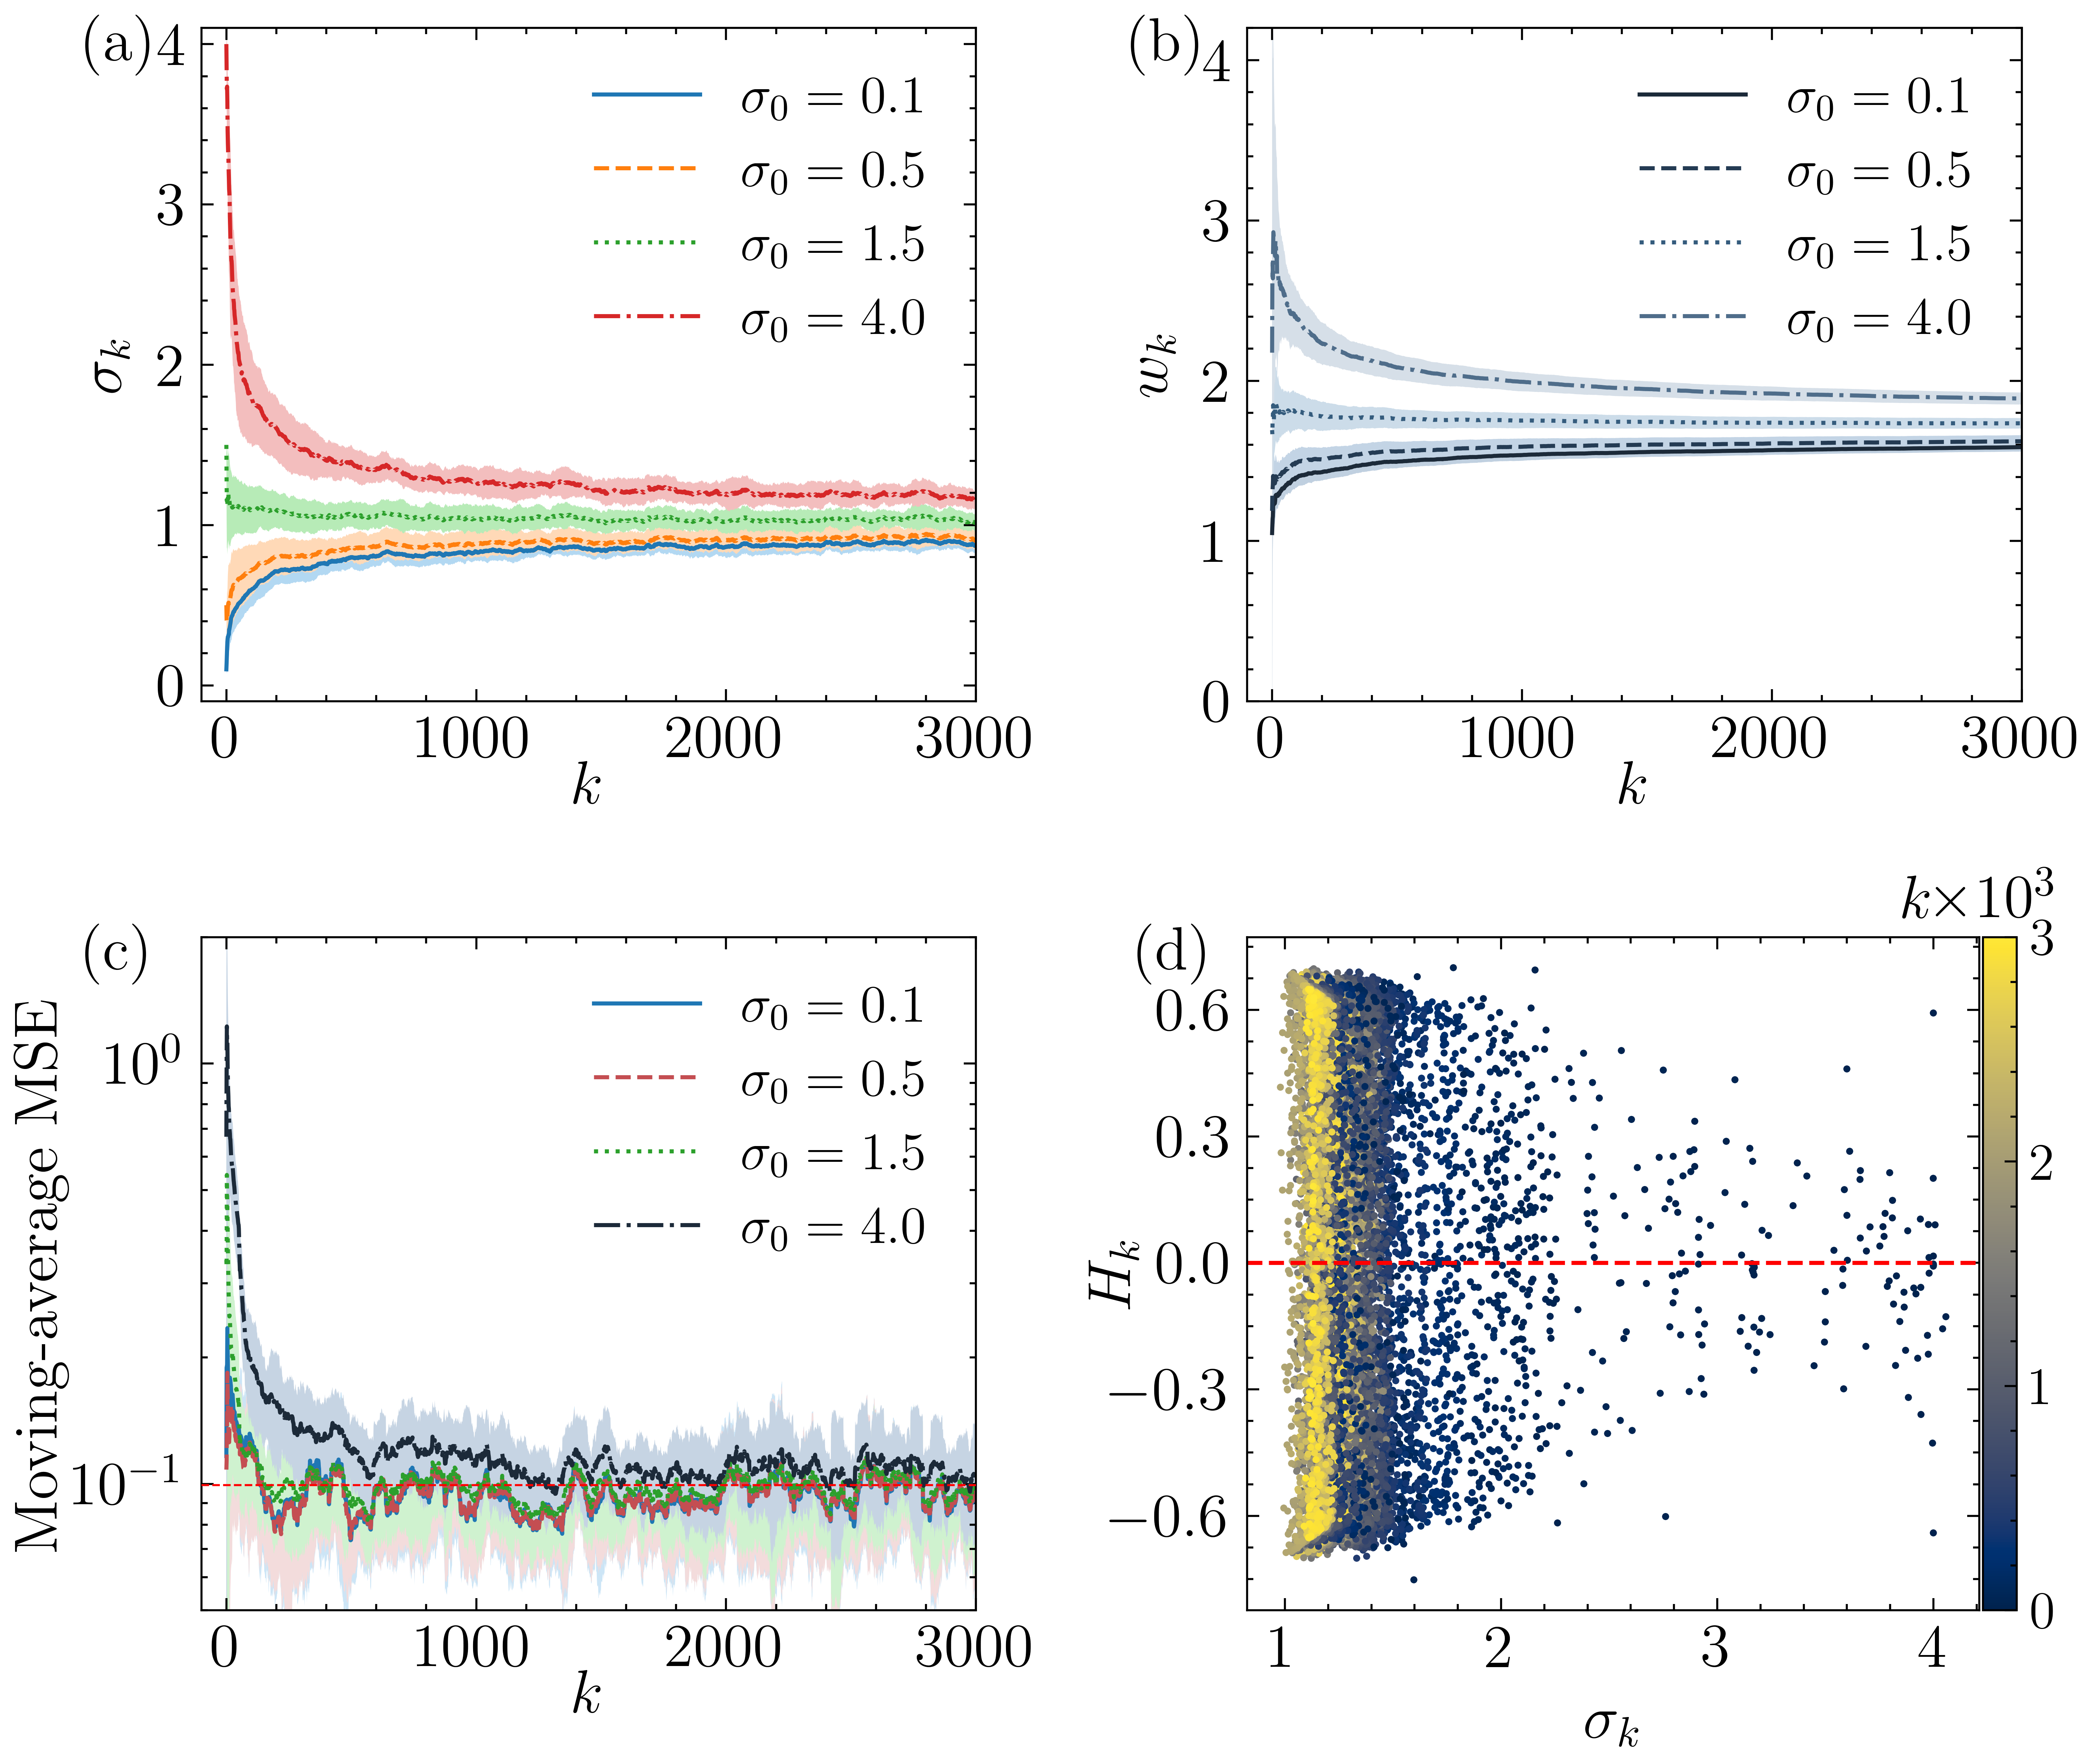

In [3]:
##### --- 绘图风格设置 ---
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import colorsys

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',   # 数学公式风格接近 Times
    'font.size': 15,
    'axes.labelsize': 15,
    'legend.fontsize': 15,
})

def lighten_color(color, amount=0.7):
    """
    Lightens the given color by mixing with white
    amount=0 returns white, amount=1 returns original color
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# ==========================================
# Create EPS-Compatible Figure with adjusted spacing
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
# 调整子图间距，增加水平间距以避免ylabel遮挡
plt.subplots_adjust(hspace=0.35, wspace=0.35)

axes = axes.flatten()
labels_txt = ['(a)', '(b)', '(c)', '(d)']

# Define colors for different panels - 三个面板使用不同色系
# Panel 1 (sigma): 经典色系 - 蓝橙绿红
colors_panel1 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
light_colors_panel1 = [lighten_color(c, amount=0.3) for c in colors_panel1]

# Panel 2 (MSE): 极清晰对比（偏硬朗）
colors_panel2 = [
    '#1f77b4',  # strong blue
    '#c44e52',  # muted red (not pink)
    '#2ca02c',  # strong green
    '#1c2a39'   # dark gray 
]
light_colors_panel2 = [lighten_color(c, amount=0.20) for c in colors_panel2]

# Panel 3 (W): 灰蓝色系（极其稳重）
colors_panel3 = [
    '#1c2a39',  # near-black blue
    '#243b53',  # deep steel blue
    '#355c7d',  # strong slate blue
    '#4f6d8a'   # lighter blue-gray
]
light_colors_panel3 = [lighten_color(c, amount=0.22) for c in colors_panel3]

iterations = np.arange(Nx_total)

# ==========================================
# Figure 1A: Sigma Convergence - Use LIGHT colors for shading
# ==========================================
ax1a = axes[0]
for i, init_val in enumerate(init_values):
    mean_traj = stats[init_val]['sigma_mean']
    std_traj = stats[init_val]['sigma_std']
    
    # Plot shaded region FIRST with light color (NO alpha)
    ax1a.fill_between(iterations, mean_traj - std_traj, mean_traj + std_traj,
                      color=light_colors_panel1[i], edgecolor='none')
    
    # Plot mean line on top with dark color
    ax1a.plot(iterations, mean_traj, color=colors_panel1[i], linewidth=1.0, 
             label=f'$\sigma_0 = {init_val}$')

ax1a.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax1a.set_ylim(-0.1, 4.1)
ax1a.set_xlabel(r'$k$', labelpad=-2)
ax1a.set_ylabel(r'$\sigma_k$',labelpad=6)
ax1a.set_yticks([0, 1, 2, 3, 4])
ax1a.set_xlim(-100, Nx_total)
ax1a.text(-0.15, 1.02, labels_txt[0], transform=ax1a.transAxes,
         fontsize=15, va='top')

# ==========================================
# Panel 2: Windowed MSE Convergence Trajectories
# 使用虚线与Panel 1区分
# ==========================================
ax2 = axes[2]

for i, init_val in enumerate(init_values):
    mean_traj = stats[init_val]['mse_mean']
    std_traj = stats[init_val]['mse_std']
    
    # Shaded region with light color (NO alpha parameter)
    ax2.fill_between(iterations, 
                     np.maximum(mean_traj - std_traj, 1e-5),  # 避免log(0)
                     mean_traj + std_traj,
                     color=light_colors_panel2[i], edgecolor='none')
    
    # Mean line with dark color
    ax2.plot(iterations, mean_traj, color=colors_panel2[i], 
             linewidth=1.0, 
             label=f'$\sigma_0 = {init_val}$')

# 添加稳态MSE参考线
avg_steady_mse = np.mean([np.mean(results_db[iv]['final_mses']) for iv in init_values])
ax2.axhline(avg_steady_mse, color='red', linestyle='--', linewidth=0.5, 
            zorder=10)
ax2.set_yscale('log')  # 对数坐标展示收敛
ax2.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax2.set_xlabel(r'$k$', labelpad=-2)
# 缩短ylabel避免遮挡，或者增加labelpad
ax2.set_ylabel(r'Moving-average MSE', labelpad=1) 
ax2.set_xlim(-100, Nx_total)
ax2.set_ylim(bottom=5e-2, top=2e0)
ax2.text(-0.15, 1.02, labels_txt[2], transform=ax2.transAxes,
         fontsize=15, va='top')

# ==========================================
# Panel 3: W convergence (使用 W1 + W2 的总和)
# ==========================================
ax3 = axes[1]

for i, init_val in enumerate(init_values):
    # 计算 W1 + W2 的总和
    W1_mean = stats[init_val]['W1_mean']
    W2_mean = stats[init_val]['W2_mean']
    W1_std = stats[init_val]['W1_std']
    W2_std = stats[init_val]['W2_std']
    
    mean_traj = W1_mean + W2_mean
    # 标准差的传播：假设独立，std(W1+W2) ≈ sqrt(std(W1)^2 + std(W2)^2)
    std_traj = np.sqrt(W1_std**2 + W2_std**2)
    
    # Shaded region with light color (NO alpha parameter)
    ax3.fill_between(iterations, 
                     np.maximum(mean_traj - std_traj, 1e-5),  # 避免log(0)
                     mean_traj + std_traj,
                     color=light_colors_panel3[i], edgecolor='none')
    
    # Mean line with dark color
    ax3.plot(iterations, mean_traj, color=colors_panel3[i], 
             linewidth=1.0,
             label=f'$\sigma_0 = {init_val}$')
ax3.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax3.set_xlabel(r'$k$', labelpad=-2)
ax3.set_ylabel(r'$w_k$',labelpad=6)
ax3.set_ylim(0, 4.2)
ax3.set_xlim(-100, Nx_total)
ax3.text(-0.15, 1.02, labels_txt[1], transform=ax3.transAxes,
         fontsize=15, va='top')

# ==========================================
# Figure 4: H_k Scatter for Init_Sigma = 4.0
# ==========================================
ax4 = axes[3]
init_val_plot = 4.0

all_sigma = []
all_H_k = []
all_iter = []

for trial_idx in range(min(5, num_trials)):
    H_k_sample = stats[init_val_plot]['H_k_samples'][trial_idx]
    sigma_sample = stats[init_val_plot]['sigma_samples'][trial_idx]
    all_sigma.extend(sigma_sample)
    all_H_k.extend(H_k_sample)
    all_iter.extend(iterations)

scatter = ax4.scatter(all_sigma, all_H_k, c=all_iter, cmap='cividis',
                     s=3, edgecolors='none', rasterized=True)

cbar = plt.colorbar(scatter, ax=ax4, pad=0.005, fraction=0.05)
cbar.set_ticks([0.0, 1000, 2000, 3000])
cbar.set_ticklabels([r'$0.0$', r'$1.0$', r'$2.0$', r'$3.0$'])
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
cbar.formatter = formatter
cbar.update_ticks()
cbar.ax.tick_params(labelsize=13)
cbar.ax.text(
    -2.4, 1.01, r'$k$',
    transform=cbar.ax.transAxes,
    fontsize=15,
    ha='left',
    va='bottom'
)
offset_text = cbar.ax.yaxis.get_offset_text()
offset_text.set_x(0.5)
offset_text.set_y(1.02)
offset_text.set_ha('center')
offset_text.set_va('bottom')

ax4.axhline(y=0, color='red', linestyle='--', linewidth=1.0)
ax4.set_xlabel(r'$\sigma_k$')
ax4.set_ylabel(r'$H_k$', labelpad=-8)
ax4.set_xticks([1,2,3,4])
ax4.set_yticks([-0.6,-0.3,0,0.3,0.6])
ax4.text(-0.15, 1.02, labels_txt[3], transform=ax4.transAxes,
         fontsize=15, va='top')

# 保存为EPS格式
fig.savefig(
    'D:/IEEE 2025 Adaptive weighted SSR/Fig10.eps',
    format='eps',
    dpi=800,
    bbox_inches='tight'
)

plt.show()

In [4]:
# ==========================================
# Print Summary Statistics
# ==========================================
print("\n" + "="*80)
print("CONVERGENCE PERFORMANCE SUMMARY")
print("="*80)
print(f"{'Init σ':<10} {'Final σ':<20} {'Final W':<20} {'Final MSE':<20} {'Conv. Time':<15}")
print("-"*80)

for init_val in init_values:
    # Final Sigma - 直接从 results_db 获取
    final_sigmas = [stats[init_val]['sigma_mean'][-1] for _ in range(num_trials)]
    final_sigma_mean = np.mean([res['final_sigma'] for res in 
                                [run_2group_sr_simulation(base_seed + t, init_val, Nx_total) 
                                 for t in range(num_trials)]])
    final_sigma_std = np.std(stats[init_val]['sigma_mean'][-100:])  # 使用最后100步的std作为估计
    
    # Final W (W1 + W2 的总和)
    final_W_mean = stats[init_val]['W1_mean'][-1] + stats[init_val]['W2_mean'][-1]
    final_W_std = np.sqrt(stats[init_val]['W1_std'][-1]**2 + stats[init_val]['W2_std'][-1]**2)
    
    # Final MSE
    final_mse_mean = np.mean(results_db[init_val]['final_mses'])
    final_mse_std = np.std(results_db[init_val]['final_mses'])
    
    # Convergence Time
    conv_time_mean = np.mean(results_db[init_val]['convergence_times'])
    conv_time_std = np.std(results_db[init_val]['convergence_times'])
    
    print(f"{init_val:<10.1f} "
          f"{final_sigma_mean:>6.4f}±{final_sigma_std:<5.4f}    "
          f"{final_W_mean:>6.4f}±{final_W_std:<5.4f}    "
          f"{final_mse_mean:>6.4f}±{final_mse_std:<5.4f}    "
          f"{conv_time_mean:>6.0f}±{conv_time_std:<5.0f}")

print("\n" + "="*80)
print("DETAILED STATISTICS BY INITIAL VALUE")
print("="*80)

for init_val in init_values:
    print(f"\n{'─'*80}")
    print(f"Init Sigma = {init_val}")
    print(f"{'─'*80}")
    
    # 计算 final sigma 的平均值
    final_sigma_vals = [stats[init_val]['sigma_mean'][-1]]
    print(f"  Final Sigma:        {stats[init_val]['sigma_mean'][-1]:.4f} ± "
          f"{stats[init_val]['sigma_std'][-1]:.4f}")
    
    # Final W (W1 + W2)
    final_W = stats[init_val]['W1_mean'][-1] + stats[init_val]['W2_mean'][-1]
    final_W_std = np.sqrt(stats[init_val]['W1_std'][-1]**2 + stats[init_val]['W2_std'][-1]**2)
    print(f"  Final W:            {final_W:.4f} ± {final_W_std:.4f}")
    
    # Final H_k - 从最后几个样本计算平均
    final_H_k_vals = [sample[-1] for sample in stats[init_val]['H_k_samples']]
    print(f"  Final H_k:          {np.mean(final_H_k_vals):.6f} ± "
          f"{np.std(final_H_k_vals):.6f}")
    
    # Final MSE
    print(f"  Final MSE:          {np.mean(results_db[init_val]['final_mses']):.6f} ± "
          f"{np.std(results_db[init_val]['final_mses']):.6f}")
    
    # Final Windowed MSE (即 mse_hist 的最后值)
    final_windowed_mses = [mse_traj[-1] for mse_traj in results_db[init_val]['mse']]
    print(f"  Final Windowed MSE: {np.mean(final_windowed_mses):.6f} ± "
          f"{np.std(final_windowed_mses):.6f}")
    
    # Convergence Time
    print(f"  Convergence Time:   {np.mean(results_db[init_val]['convergence_times']):.0f} ± "
          f"{np.std(results_db[init_val]['convergence_times']):.0f} steps")
    
    # 初始MSE (前100步)
    init_mse = np.mean(stats[init_val]['mse_mean'][:100])
    final_mse = np.mean(results_db[init_val]['final_mses'])
    improvement = init_mse / final_mse if final_mse > 0 else float('inf')
    
    print(f"  Initial MSE (0-100): {init_mse:.6f}")
    print(f"  MSE Improvement:     {improvement:.2f}x")

print("\n" + "="*80)

# ==========================================
# Comparison Table
# ==========================================
print("\n" + "="*80)
print("ALGORITHM ROBUSTNESS ANALYSIS")
print("="*80)

# 找出最快和最慢收敛的初始值
conv_times = {init_val: np.mean(results_db[init_val]['convergence_times']) 
              for init_val in init_values}
fastest_init = min(conv_times, key=conv_times.get)
slowest_init = max(conv_times, key=conv_times.get)

print(f"\nFastest Convergence: Init_σ = {fastest_init} ({conv_times[fastest_init]:.0f} steps)")
print(f"Slowest Convergence: Init_σ = {slowest_init} ({conv_times[slowest_init]:.0f} steps)")
print(f"Convergence Ratio:   {conv_times[slowest_init]/conv_times[fastest_init]:.2f}x")

# MSE性能比较
final_mses = {init_val: np.mean(results_db[init_val]['final_mses']) 
              for init_val in init_values}
best_mse_init = min(final_mses, key=final_mses.get)
worst_mse_init = max(final_mses, key=final_mses.get)

print(f"\nBest Final MSE:      Init_σ = {best_mse_init} (MSE = {final_mses[best_mse_init]:.6f})")
print(f"Worst Final MSE:     Init_σ = {worst_mse_init} (MSE = {final_mses[worst_mse_init]:.6f})")
print(f"MSE Variance:        {np.std(list(final_mses.values())):.6f}")

print("\n" + "="*80 + "\n")


CONVERGENCE PERFORMANCE SUMMARY
Init σ     Final σ              Final W              Final MSE            Conv. Time     
--------------------------------------------------------------------------------
0.1        0.8759±0.0089    1.5859±0.0276    0.0953±0.0058         6±18   
0.5        0.9144±0.0098    1.6227±0.0383    0.0955±0.0055         3±12   
1.5        1.0332±0.0088    1.7350±0.0328    0.0985±0.0054        20±30   
4.0        1.1963±0.0093    1.8895±0.0379    0.1081±0.0064       121±117  

DETAILED STATISTICS BY INITIAL VALUE

────────────────────────────────────────────────────────────────────────────────
Init Sigma = 0.1
────────────────────────────────────────────────────────────────────────────────
  Final Sigma:        0.8741 ± 0.0472
  Final W:            1.5859 ± 0.0276
  Final H_k:          -0.010918 ± 0.479524
  Final MSE:          0.095287 ± 0.005805
  Final Windowed MSE: 0.098105 ± 0.042261
  Convergence Time:   6 ± 18 steps
  Initial MSE (0-100): 0.141331
  MSE Im